# ColorMNIST Data

This notebook demonstrates how to load and analyze the generated ColorMNIST data.



==================== Diagnostic Test for hl_model ====================


NameError: name 'det_hl_dict' is not defined

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from operations import Intervention
import os
from train_cmnist_models import ImageColorizerUNet

# Set up plotting
plt.rcParams['figure.figsize'] = (12, 8)


In [2]:
# Load the generated ColorMNIST data
data_dir = 'data/cmnist'

# Load the data
Dll_samples = torch.load(f'{data_dir}/dll_samples.pkl')
Dhl_samples = torch.load(f'{data_dir}/dhl_samples.pkl')
omega       = torch.load(f'{data_dir}/intervention_mapping.pkl')

# Load low-level U-Net model
ll_model_state = torch.load(f'{data_dir}/ll_model_unet.pth')
ll_model       = ImageColorizerUNet()
ll_model.load_state_dict(ll_model_state)
ll_model.eval()

U_ll_hat = torch.load(f'{data_dir}/U_ll_hat.pkl')

# Load high-level linear model
hl_model = torch.load(f'{data_dir}/hl_model.pkl')

U_hl_hat = torch.load(f'{data_dir}/U_hl_hat.pkl')

print("Data loaded successfully!")
print(f"  - Low-level noise shape: {U_ll_hat.shape}")
print(f"  - High-level noise shape: {U_hl_hat.shape}")

Data loaded successfully!
  - Low-level noise shape: torch.Size([1000, 3, 32, 32])
  - High-level noise shape: torch.Size([1000, 1])


/Users/giofelekis/opt/anaconda3/envs/erica/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.5.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# Define HL variable names from data_generator.py
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'

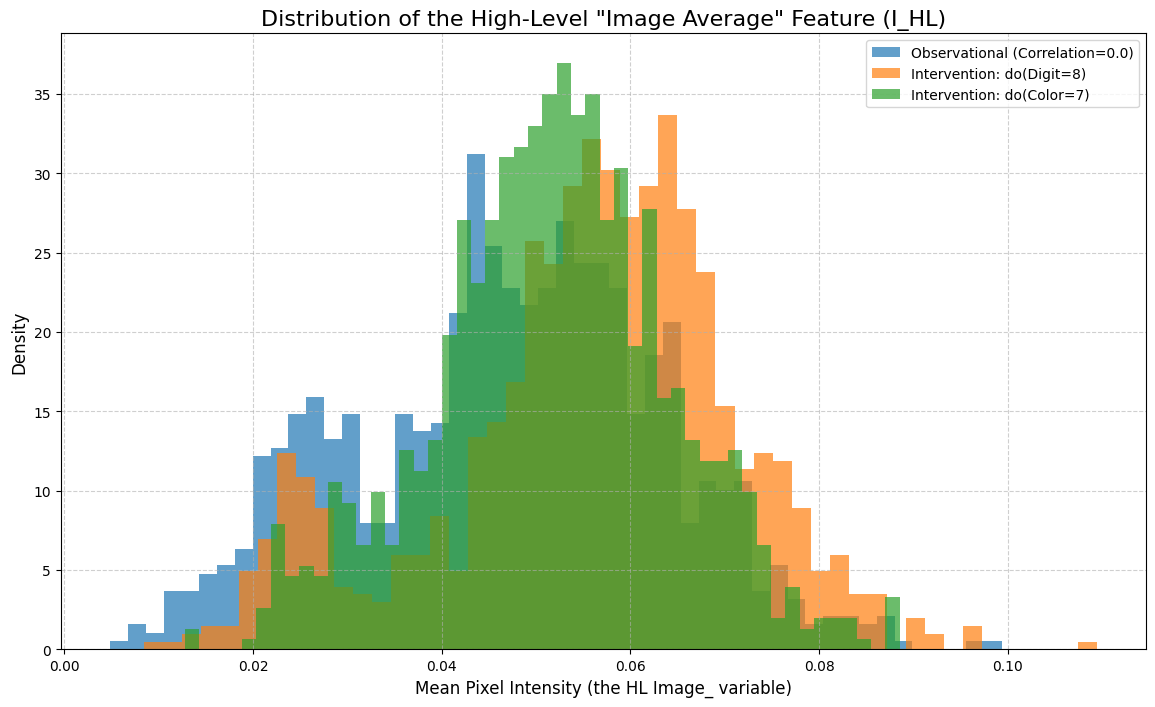

--- Distribution Statistics for HL 'Image_' Variable ---

Observational (Correlation=0.0):
  Mean:    0.0470
  Std Dev: 0.0164
  Min:     0.0049
  Max:     0.0993

Intervention do(Digit=8):
  Mean:    0.0556
  Std Dev: 0.0158

Intervention do(Color=7):
  Mean:    0.0516
  Std Dev: 0.0126


In [4]:
# --- 1. Extract the "Image Average" variable ---
# This variable is the last column of the HL data tensors

# Get observational data
obs_hl_data = Dhl_samples[None]
obs_averages = obs_hl_data[:, -1].numpy()

# Get a "do(Digit=...)" intervention
# We find the intervention object in the Dhl_samples keys
eta_do_digit_8 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == {D_HL: 8}:
        eta_do_digit_8 = eta
        break
        
int_digit_data = Dhl_samples[eta_do_digit_8]
int_digit_averages = int_digit_data[:, -1].numpy()

# Get a "do(Color=...)" intervention
eta_do_color_7 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == {C_HL: 7}:
        eta_do_color_7 = eta
        break

int_color_data = Dhl_samples[eta_do_color_7]
int_color_averages = int_color_data[:, -1].numpy()


# --- 2. Plot the Histograms ---
plt.figure(figsize=(14, 8))
plt.hist(obs_averages, bins=50, alpha=0.7, label=f'Observational (Correlation=0.0)', density=True)
plt.hist(int_digit_averages, bins=50, alpha=0.7, label=f'Intervention: do(Digit=8)', density=True)
plt.hist(int_color_averages, bins=50, alpha=0.7, label=f'Intervention: do(Color=7)', density=True)

plt.title('Distribution of the High-Level "Image Average" Feature (I_HL)', fontsize=16)
plt.xlabel('Mean Pixel Intensity (the HL Image_ variable)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 3. Print Descriptive Statistics ---
print("--- Distribution Statistics for HL 'Image_' Variable ---")
print(f"\nObservational (Correlation=0.0):")
print(f"  Mean:    {obs_averages.mean():.4f}")
print(f"  Std Dev: {obs_averages.std():.4f}")
print(f"  Min:     {obs_averages.min():.4f}")
print(f"  Max:     {obs_averages.max():.4f}")

print(f"\nIntervention do(Digit=8):")
print(f"  Mean:    {int_digit_averages.mean():.4f}")
print(f"  Std Dev: {int_digit_averages.std():.4f}")

print(f"\nIntervention do(Color=7):")
print(f"  Mean:    {int_color_averages.mean():.4f}")
print(f"  Std Dev: {int_color_averages.std():.4f}")

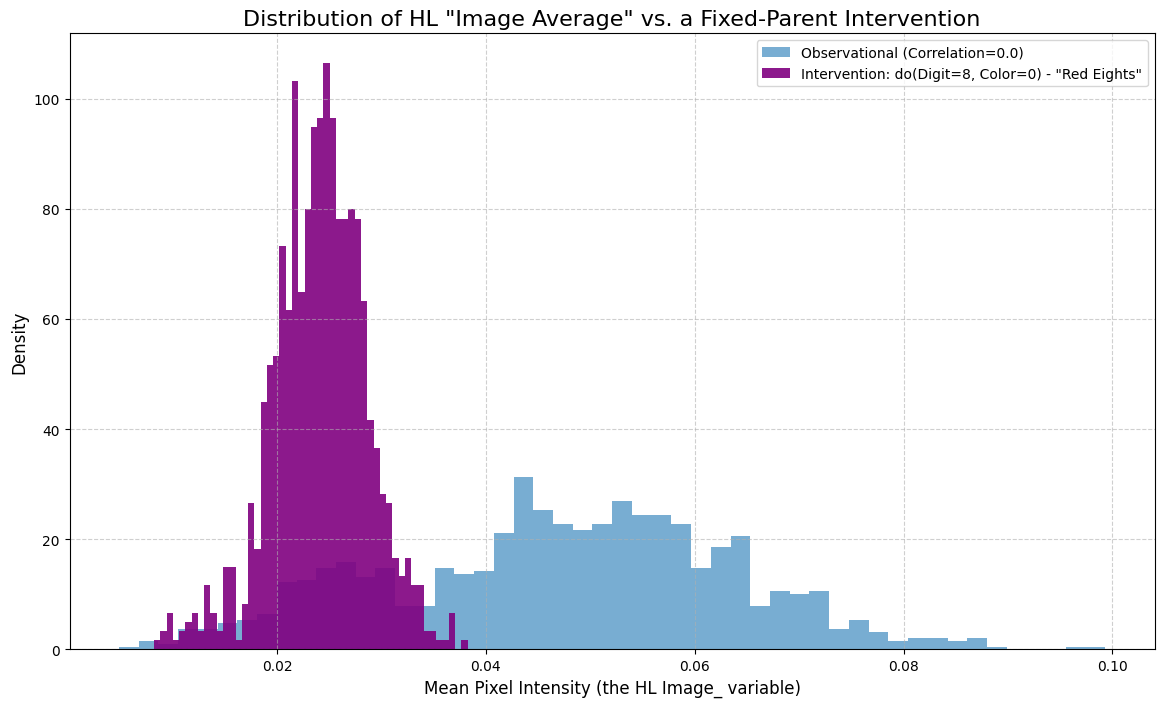

--- Distribution Statistics for HL 'Image_' Variable ---

Observational (Correlation=0.0):
  Mean:    0.0470
  Std Dev: 0.0164

Intervention do(Digit=8, Color=0):
  Mean:    0.0241
  Std Dev: 0.0045


In [5]:
# --- 1. Define HL variable names (from data_generator.py) ---
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'

# --- 2. Extract Data for the new intervention ---

# Get observational data (for comparison)
obs_hl_data = Dhl_samples[None]
obs_averages = obs_hl_data[:, -1].numpy()

# Find the intervention for "red eights"
# From data_generator.py:
#   - "red" is Color = 0
#   - "eight" is Digit = 8
target_intervention = {D_HL: 8, C_HL: 0} 
eta_do_digit_8_color_0 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == target_intervention:
        eta_do_digit_8_color_0 = eta
        break

if eta_do_digit_8_color_0 is None:
    print(f"Error: Could not find intervention for {target_intervention}")
else:
    # Extract the image average (last column) for this intervention
    int_d8_c0_data = Dhl_samples[eta_do_digit_8_color_0]
    int_d8_c0_averages = int_d8_c0_data[:, -1].numpy()

    # --- 3. Plot the Histograms ---
    plt.figure(figsize=(14, 8))
    plt.hist(obs_averages, bins=50, alpha=0.6, label=f'Observational (Correlation=0.0)', density=True)
    plt.hist(int_d8_c0_averages, bins=50, alpha=0.9, label=f'Intervention: do(Digit=8, Color=0) - "Red Eights"', density=True, color='purple')

    plt.title('Distribution of HL "Image Average" vs. a Fixed-Parent Intervention', fontsize=16)
    plt.xlabel('Mean Pixel Intensity (the HL Image_ variable)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # --- 4. Print Descriptive Statistics ---
    print("--- Distribution Statistics for HL 'Image_' Variable ---")
    print(f"\nObservational (Correlation=0.0):")
    print(f"  Mean:    {obs_averages.mean():.4f}")
    print(f"  Std Dev: {obs_averages.std():.4f}")

    print(f"\nIntervention do(Digit=8, Color=0):")
    print(f"  Mean:    {int_d8_c0_averages.mean():.4f}")
    print(f"  Std Dev: {int_d8_c0_averages.std():.4f}")

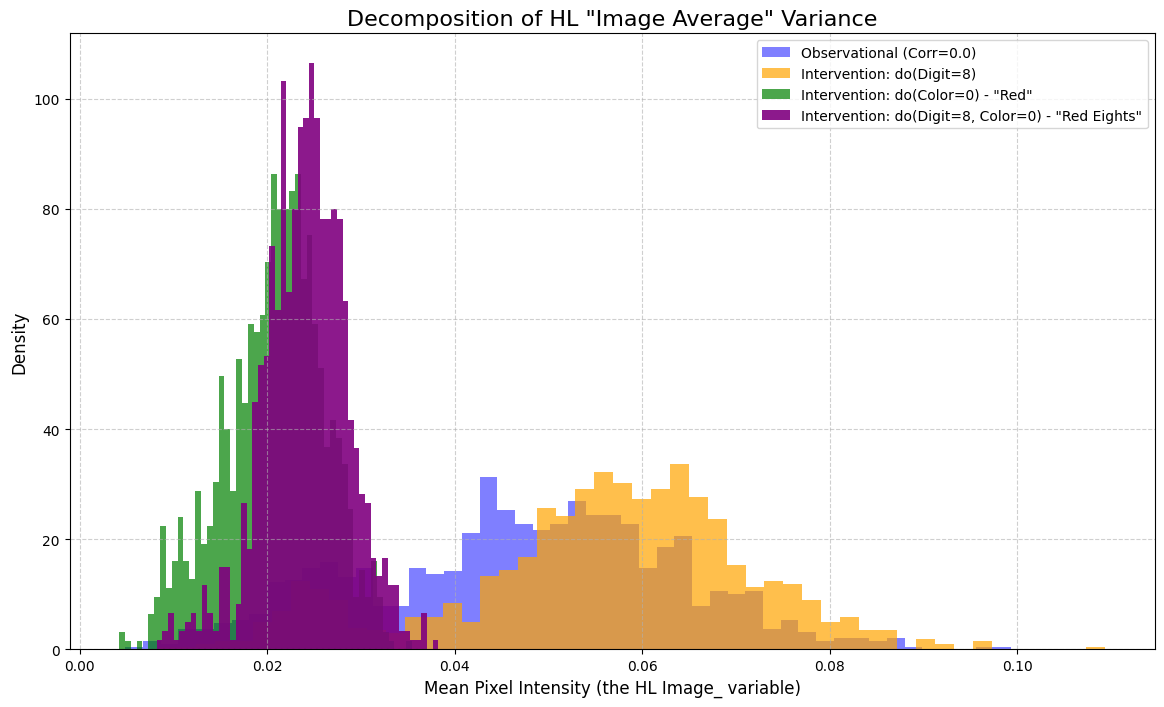

--- Distribution Statistics for HL 'Image_' Variable ---

Observational (Corr=0.0):
  Mean:    0.0470
  Std Dev: 0.0164 (Total Variance)

Intervention do(Digit=8):
  Mean:    0.0556
  Std Dev: 0.0158 (Variance from Color)

Intervention do(Color=0) - 'Red':
  Mean:    0.0208
  Std Dev: 0.0054 (Variance from Digit)

Intervention do(Digit=8, Color=0) - 'Red Eights':
  Mean:    0.0241
  Std Dev: 0.0045 (Base Noise U_image)


In [6]:
# --- 1. Define HL variable names (from data_generator.py) ---
D_HL, C_HL, I_HL = 'Digit_', 'Color_', 'Image_'

# --- 2. Extract Data for all four scenarios ---

# (1) Observational
obs_hl_data = Dhl_samples[None]
obs_averages = obs_hl_data[:, -1].numpy()

# (2) Intervention: do(Digit=8)
eta_do_digit_8 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == {D_HL: 8}:
        eta_do_digit_8 = eta
        break
int_digit_data = Dhl_samples[eta_do_digit_8]
int_digit_averages = int_digit_data[:, -1].numpy()

# (3) Intervention: do(Color=0) - "Red"
# From data_generator.py, "red" is Color 0
eta_do_color_0 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == {C_HL: 0}:
        eta_do_color_0 = eta
        break
int_color_data = Dhl_samples[eta_do_color_0]
int_color_averages = int_color_data[:, -1].numpy()

# (4) Intervention: do(Digit=8, Color=0) - "Red Eights"
eta_do_digit_8_color_0 = None
for eta in Dhl_samples.keys():
    if eta is not None and eta.vv() == {D_HL: 8, C_HL: 0}:
        eta_do_digit_8_color_0 = eta
        break
int_d8_c0_data = Dhl_samples[eta_do_digit_8_color_0]
int_d8_c0_averages = int_d8_c0_data[:, -1].numpy()


# --- 3. Plot all four Histograms ---
plt.figure(figsize=(14, 8))
plt.hist(obs_averages, bins=50, alpha=0.5, label=f'Observational (Corr=0.0)', density=True, color='blue')
plt.hist(int_digit_averages, bins=50, alpha=0.7, label=f'Intervention: do(Digit=8)', density=True, color='orange')
plt.hist(int_color_averages, bins=50, alpha=0.7, label=f'Intervention: do(Color=0) - "Red"', density=True, color='green')
plt.hist(int_d8_c0_averages, bins=50, alpha=0.9, label=f'Intervention: do(Digit=8, Color=0) - "Red Eights"', density=True, color='purple')

plt.title('Decomposition of HL "Image Average" Variance', fontsize=16)
plt.xlabel('Mean Pixel Intensity (the HL Image_ variable)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# --- 4. Print Descriptive Statistics ---
print("--- Distribution Statistics for HL 'Image_' Variable ---")
print(f"\nObservational (Corr=0.0):")
print(f"  Mean:    {obs_averages.mean():.4f}")
print(f"  Std Dev: {obs_averages.std():.4f} (Total Variance)")

print(f"\nIntervention do(Digit=8):")
print(f"  Mean:    {int_digit_averages.mean():.4f}")
print(f"  Std Dev: {int_digit_averages.std():.4f} (Variance from Color)")

print(f"\nIntervention do(Color=0) - 'Red':")
print(f"  Mean:    {int_color_averages.mean():.4f}")
print(f"  Std Dev: {int_color_averages.std():.4f} (Variance from Digit)")

print(f"\nIntervention do(Digit=8, Color=0) - 'Red Eights':")
print(f"  Mean:    {int_d8_c0_averages.mean():.4f}")
print(f"  Std Dev: {int_d8_c0_averages.std():.4f} (Base Noise U_image)")

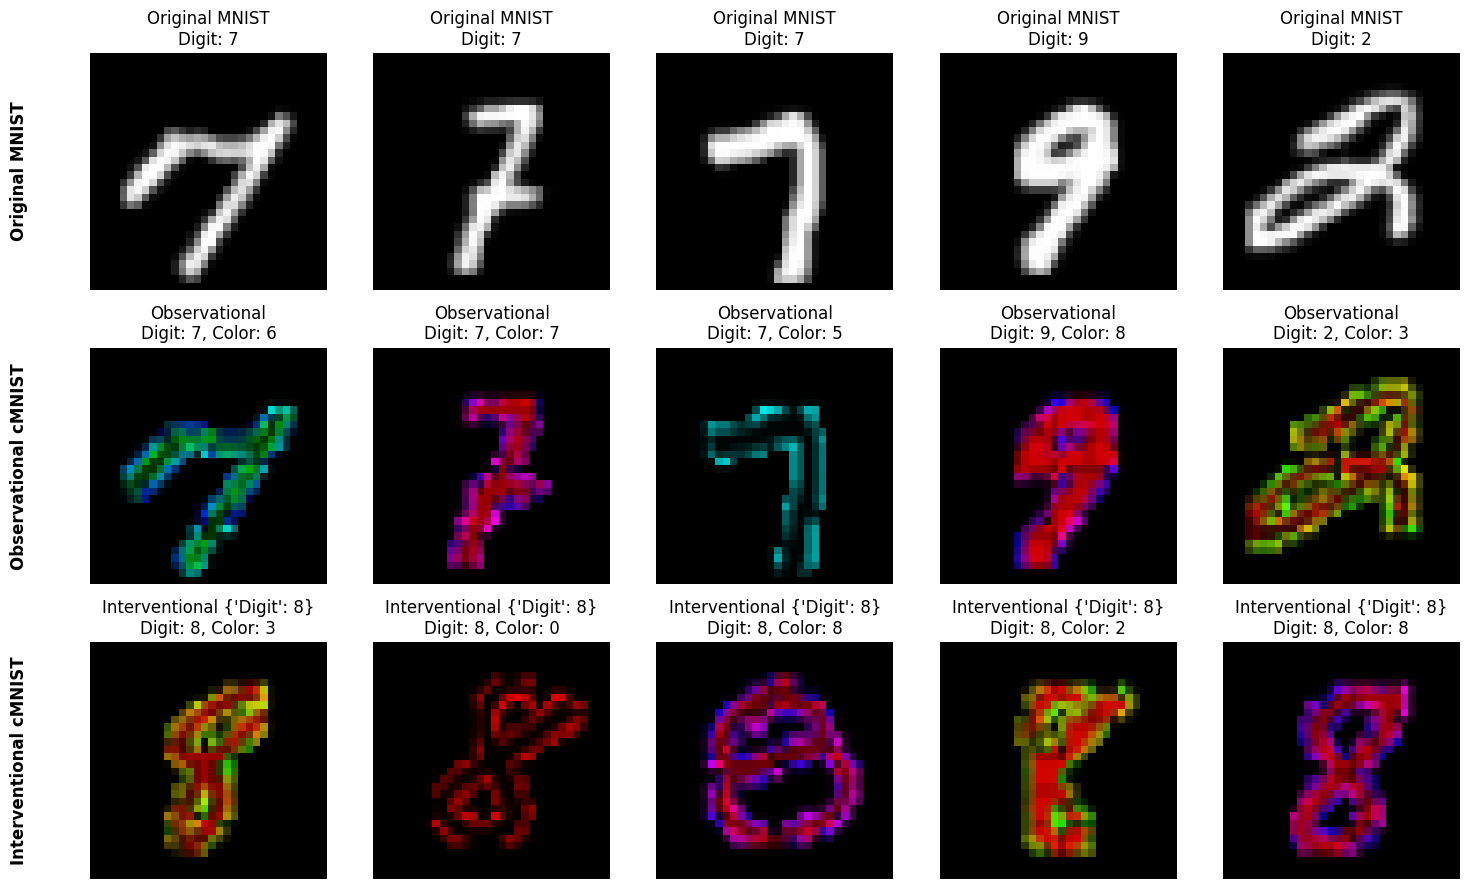

In [7]:
# Visualize sample images: Original MNIST, Observational, and Interventional
obs_data = Dll_samples[None]
obs_images, obs_shapes, obs_digits, obs_colors = obs_data

iota1 = list(omega.keys())[2]  # Pick an intervention
int_data = Dll_samples[iota1]
int_images, int_shapes, int_digits, int_colors = int_data

n_samples = 5
fig, axes = plt.subplots(3, n_samples, figsize=(15, 9))

for i in range(n_samples):
    # Row 1: Original MNIST shapes (grayscale)
    shape = obs_shapes[i].squeeze()  # Remove channel dimension
    axes[0, i].imshow(shape, cmap='gray')
    axes[0, i].set_title(f'Original MNIST\nDigit: {obs_digits[i].item()}')
    axes[0, i].axis('off')
    
    # Row 2: Observational colored images
    img = obs_images[i].permute(1, 2, 0)  # Convert from CHW to HWC
    axes[1, i].imshow(img)
    axes[1, i].set_title(f'Observational\nDigit: {obs_digits[i].item()}, Color: {obs_colors[i].item()}')
    axes[1, i].axis('off')
    
    # Row 3: Interventional colored images
    int_img = int_images[i].permute(1, 2, 0)  # Convert from CHW to HWC
    axes[2, i].imshow(int_img)
    axes[2, i].set_title(f'Interventional {iota1.vv()}\nDigit: {int_digits[i].item()}, Color: {int_colors[i].item()}')
    axes[2, i].axis('off')

# Add row labels
axes[0, 0].text(-0.3, 0.5, 'Original MNIST', transform=axes[0, 0].transAxes, 
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[1, 0].text(-0.3, 0.5, 'Observational cMNIST', transform=axes[1, 0].transAxes, 
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')
axes[2, 0].text(-0.3, 0.5, 'Interventional cMNIST', transform=axes[2, 0].transAxes, 
                rotation=90, va='center', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


Observational data defined:
  - Low-level shape: torch.Size([1000, 3, 32, 32]) (images)
  - High-level shape: torch.Size([1000, 21])
COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS

1. RESIDUAL DIAGNOSTICS
------------------------------


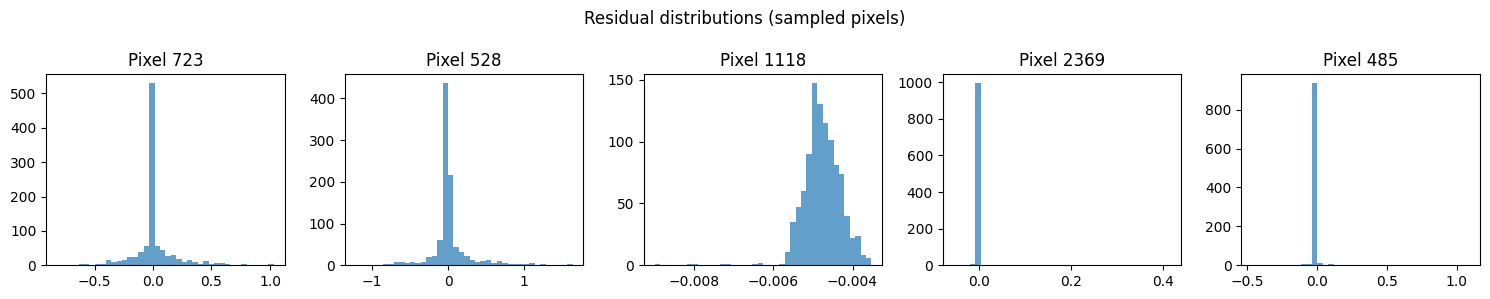

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.60252464..1.2534138].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.1325883..1.3280149].


R² of predicting residual (pixel 723) from labels: 0.0007
✓ Residual appears independent of labels (good exogenous noise).


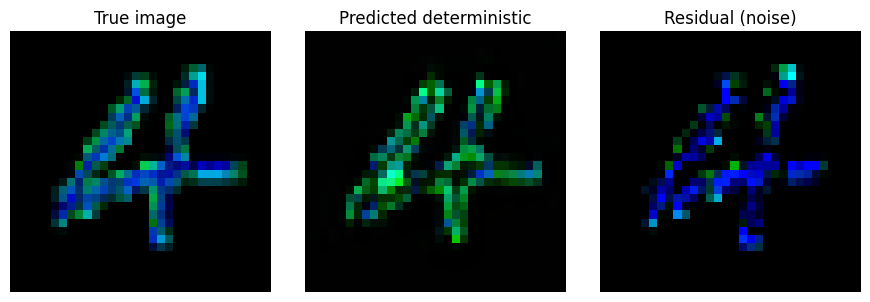


2. COUNTERFACTUAL CONSISTENCY SCORES
----------------------------------------


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


Consistency Scores:
  digit_variance: 0.044378
  color_variance: 0.000596
  noise_corr: 1.000000

3. COLOR HUE ANALYSIS
-------------------------
Mean pairwise JS divergence over hue histograms: 0.5728

4. VISUAL COUNTERFACTUAL SWEEP
-----------------------------------


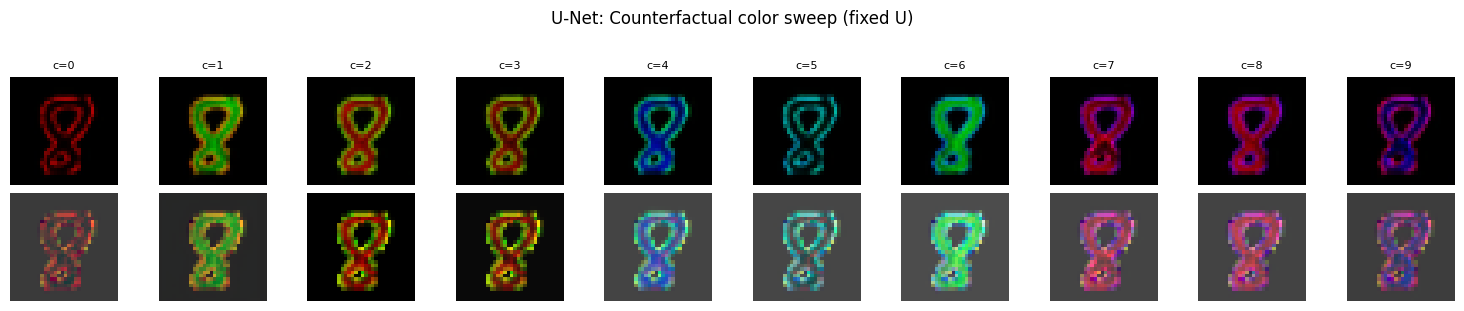


5. SUMMARY INTERPRETATION
------------------------------
Residual Independence:
Residuals are independent of labels (good)

Counterfactual Consistency:
Moderate digit shape changes (acceptable)
Low color sensitivity (needs improvement)
Noise component is stable (excellent)

Color Hue Diversity: 0.5728
High color diversity (good)

DIAGNOSTICS COMPLETE


In [8]:
# ===== COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS =====

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import rgb_to_hsv
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Define the observational data tuple from loaded data
ll_obs_data_tuple = Dll_samples[None]  # Get observational (no intervention) data
hl_obs_data = Dhl_samples[None]        # Get observational high-level data

print("Observational data defined:")
print(f"  - Low-level shape: {ll_obs_data_tuple[0].shape} (images)")
print(f"  - High-level shape: {hl_obs_data.shape}")

def comprehensive_counterfactual_diagnostics(ll_obs_data_tuple, ll_model_unet, U_ll_hat_unet, 
                                         num_samples=5, bins=36, v_thresh=0.1):
    """
    Comprehensive diagnostics for counterfactual analysis including:
    1. Residual diagnostics (independence, distribution)
    2. Counterfactual consistency scores
    3. Color hue analysis
    4. Visual counterfactual sweep
    """
    
    print("=" * 60)
    print("COMPREHENSIVE COUNTERFACTUAL DIAGNOSTICS")
    print("=" * 60)
    
    # Unpack data
    final_images, img_shapes, digits, colors = ll_obs_data_tuple
    
    # ===== 1. RESIDUAL DIAGNOSTICS =====
    print("\n1. RESIDUAL DIAGNOSTICS")
    print("-" * 30)
    
    # Flatten residuals for analysis
    U = U_ll_hat_unet.view(U_ll_hat_unet.size(0), -1).detach().cpu().numpy()
    
    # Sample pixels for analysis
    sample_pixels = np.random.choice(U.shape[1], size=num_samples, replace=False)
    resid_samples = U[:, sample_pixels]
    
    # Histogram check
    fig, axs = plt.subplots(1, num_samples, figsize=(15, 3))
    for i, pix in enumerate(sample_pixels):
        axs[i].hist(resid_samples[:, i], bins=40, alpha=0.7)
        axs[i].set_title(f"Pixel {pix}")
    plt.suptitle("Residual distributions (sampled pixels)")
    plt.tight_layout()
    plt.show()
    
    # Dependence check
    digits_np = digits.cpu().numpy()
    colors_np = colors.cpu().numpy()
    X = np.stack([digits_np, colors_np], axis=1)
    
    # Test first sampled pixel
    y = resid_samples[:, 0]
    linreg = LinearRegression().fit(X, y)
    y_pred = linreg.predict(X)
    r2_resid = r2_score(y, y_pred)
    
    print(f"R² of predicting residual (pixel {sample_pixels[0]}) from labels: {r2_resid:.4f}")
    if abs(r2_resid) < 0.05:
        print("✓ Residual appears independent of labels (good exogenous noise).")
    else:
        print("⚠ Residual still has label-dependent structure.")
    
    # Visual sanity check
    idx = np.random.randint(0, len(U_ll_hat_unet))
    resid_img = U_ll_hat_unet[idx].permute(1,2,0).detach().cpu().numpy()
    true_img = final_images[idx].permute(1,2,0).cpu().numpy()
    pred_img = (true_img - resid_img)
    
    fig, axs = plt.subplots(1, 3, figsize=(9,3))
    axs[0].imshow(true_img, cmap="gray"); axs[0].set_title("True image")
    axs[1].imshow(pred_img, cmap="gray"); axs[1].set_title("Predicted deterministic")
    axs[2].imshow(resid_img, cmap="gray"); axs[2].set_title("Residual (noise)")
    for ax in axs: ax.axis("off")
    plt.tight_layout()
    plt.show()
    
    # ===== 2. COUNTERFACTUAL CONSISTENCY SCORES =====
    print("\n2. COUNTERFACTUAL CONSISTENCY SCORES")
    print("-" * 40)
    
    # Helper function for image scaling
    def to01(img_t):
        x = img_t.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1.0) / 2.0
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        return x.clamp(0, 1).numpy()
    
    # Generate counterfactuals
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    ll_model_unet = ll_model_unet.to(device).eval()
    
    idx = np.random.randint(0, len(U_ll_hat_unet))
    with torch.no_grad():
        base_shape = img_shapes[idx:idx+1].to(device)
        base_digit = digits[idx:idx+1].to(device)
        U_fixed = U_ll_hat_unet[idx:idx+1].to(device)
        
        dets = []
        outs = []
        for c in range(10):
            c_tensor = torch.tensor([c], device=device)
            det = ll_model_unet(base_shape, base_digit, c_tensor)
            ycf = det + U_fixed
            dets.append(det.cpu())
            outs.append(ycf.cpu())
    
    # Calculate consistency scores
    D = torch.stack(dets, dim=0)
    O = torch.stack(outs, dim=0)
    
    # Digit shape invariance
    D_gray = D.mean(1)
    var_digit = D_gray.var(0).mean().item()
    
    # Color sensitivity
    mean_colors = O.view(O.size(0), O.size(1), -1).mean(-1)
    var_color = mean_colors.var(0).mean().item()
    
    # Noise stability
    U = O - D
    U_flat = U.view(U.size(0), -1).cpu().numpy()
    corr_mat = np.corrcoef(U_flat)
    mean_corr = (corr_mat[np.triu_indices_from(corr_mat, k=1)]).mean()
    
    consistency_scores = {
        "digit_variance": var_digit,
        "color_variance": var_color,
        "noise_corr": mean_corr
    }
    
    print("Consistency Scores:")
    for key, value in consistency_scores.items():
        print(f"  {key}: {value:.6f}")
    
    # ===== 3. COLOR HUE ANALYSIS =====
    print("\n3. COLOR HUE ANALYSIS")
    print("-" * 25)
    
    def hue_hist(img_chw, bins=36, v_thresh=0.1):
        x = img_chw.detach().cpu().float()
        if x.min() >= -1.05 and x.max() <= 1.05:
            x = (x + 1) / 2
        else:
            m, M = x.min(), x.max()
            x = (x - m) / (M - m + 1e-8)
        
        rgb = x.permute(1,2,0).numpy()
        hsv = rgb_to_hsv(rgb)
        H, S, V = hsv[...,0], hsv[...,1], hsv[...,2]
        
        mask = V > v_thresh
        if mask.sum() == 0:
            return np.ones(bins) / bins
        
        h = H[mask].ravel()
        hist, _ = np.histogram(h, bins=bins, range=(0,1), density=False)
        hist = hist.astype(np.float64)
        hist /= hist.sum() + 1e-12
        return hist
    
    def js_divergence(p, q):
        m = 0.5*(p+q)
        def kl(a,b):
            a = np.clip(a, 1e-12, 1.0)
            b = np.clip(b, 1e-12, 1.0)
            return np.sum(a * np.log(a/b))
        return 0.5*kl(p,m) + 0.5*kl(q,m)
    
    def color_hue_js_score(dets, bins=36, v_thresh=0.1):
        Hs = [hue_hist(det[0], bins=bins, v_thresh=v_thresh) for det in dets]
        n = len(Hs)
        js_vals = []
        for i in range(n):
            for j in range(i+1, n):
                js_vals.append(js_divergence(Hs[i], Hs[j]))
        return float(np.mean(js_vals)) if js_vals else 0.0
    
    js_hue = color_hue_js_score(dets, bins=bins, v_thresh=v_thresh)
    print(f"Mean pairwise JS divergence over hue histograms: {js_hue:.4f}")
    
    # ===== 4. VISUAL COUNTERFACTUAL SWEEP =====
    print("\n4. VISUAL COUNTERFACTUAL SWEEP")
    print("-" * 35)
    
    # Plot counterfactuals
    fig, axs = plt.subplots(2, 10, figsize=(15, 3))
    for c in range(10):
        axs[0, c].imshow(to01(dets[c][0].permute(1,2,0))); axs[0, c].axis("off")
        axs[0, c].set_title(f"c={c}", fontsize=8)
        axs[1, c].imshow(to01(outs[c][0].permute(1,2,0))); axs[1, c].axis("off")
    axs[0,0].set_ylabel("deterministic", fontsize=9)
    axs[1,0].set_ylabel("with noise", fontsize=9)
    plt.suptitle("U-Net: Counterfactual color sweep (fixed U)", y=1.02)
    plt.tight_layout()
    plt.show()
    
    # ===== 5. SUMMARY INTERPRETATION =====
    print("\n5. SUMMARY INTERPRETATION")
    print("-" * 30)
    
    print("Residual Independence:")
    if abs(r2_resid) < 0.05:
        print("Residuals are independent of labels (good)")
    else:
        print("Residuals still depend on labels (needs improvement)")
    
    print("\nCounterfactual Consistency:")
    if var_digit < 0.01:
        print("Digit shape preserved across colors (good)")
    elif var_digit < 0.1:
        print("Moderate digit shape changes (acceptable)")
    else:
        print("Significant digit shape changes (needs improvement)")
    
    if var_color > 0.1:
        print("Colors change appropriately (good)")
    elif var_color > 0.01:
        print("Moderate color sensitivity (acceptable)")
    else:
        print("Low color sensitivity (needs improvement)")
    
    if mean_corr > 0.95:
        print("Noise component is stable (excellent)")
    elif mean_corr > 0.8:
        print("Noise component is mostly stable (good)")
    else:
        print("Noise component varies (needs improvement)")
    
    print(f"\nColor Hue Diversity: {js_hue:.4f}")
    if js_hue > 0.3:
        print("High color diversity (good)")
    elif js_hue > 0.1:
        print("Moderate color diversity (acceptable)")
    else:
        print("Low color diversity (needs improvement)")
    
    print("\n" + "=" * 60)
    print("DIAGNOSTICS COMPLETE")
    print("=" * 60)
    
    return {
        'residual_r2': r2_resid,
        'consistency_scores': consistency_scores,
        'js_hue': js_hue,
        'dets': dets,
        'outs': outs
    }

# Run comprehensive diagnostics
results = comprehensive_counterfactual_diagnostics(
    ll_obs_data_tuple, 
    ll_model,  # Use ll_model instead of ll_model_unet
    U_ll_hat,  # Use U_ll_hat instead of U_ll_hat_unet
    num_samples=5,
    bins=36,
    v_thresh=0.1
)

GAUSSIANITY TESTS FOR NOISE

1. LOW-LEVEL NOISE GAUSSIANITY
----------------------------------------
Pixel 1262:
  D'Agostino-Pearson: stat=265.5347, p=0.0000
  Shapiro-Wilk: stat=0.6617, p=0.0000
  Anderson-Darling: stat=142.4400, critical=0.7840

Pixel 1420:
  D'Agostino-Pearson: stat=379.2002, p=0.0000
  Shapiro-Wilk: stat=0.6879, p=0.0000
  Anderson-Darling: stat=129.4684, critical=0.7840

Pixel 2581:
  D'Agostino-Pearson: stat=433.5271, p=0.0000
  Shapiro-Wilk: stat=0.6485, p=0.0000
  Anderson-Darling: stat=142.4443, critical=0.7840

Pixel 1479:
  D'Agostino-Pearson: stat=745.4104, p=0.0000
  Shapiro-Wilk: stat=0.3512, p=0.0000
  Anderson-Darling: stat=252.1128, critical=0.7840

Pixel 2205:
  D'Agostino-Pearson: stat=761.0993, p=0.0000
  Shapiro-Wilk: stat=0.7538, p=0.0000
  Anderson-Darling: stat=45.2719, critical=0.7840

Pixel 1320:
  D'Agostino-Pearson: stat=964.3660, p=0.0000
  Shapiro-Wilk: stat=0.3698, p=0.0000
  Anderson-Darling: stat=244.7449, critical=0.7840

Pixel 2230:


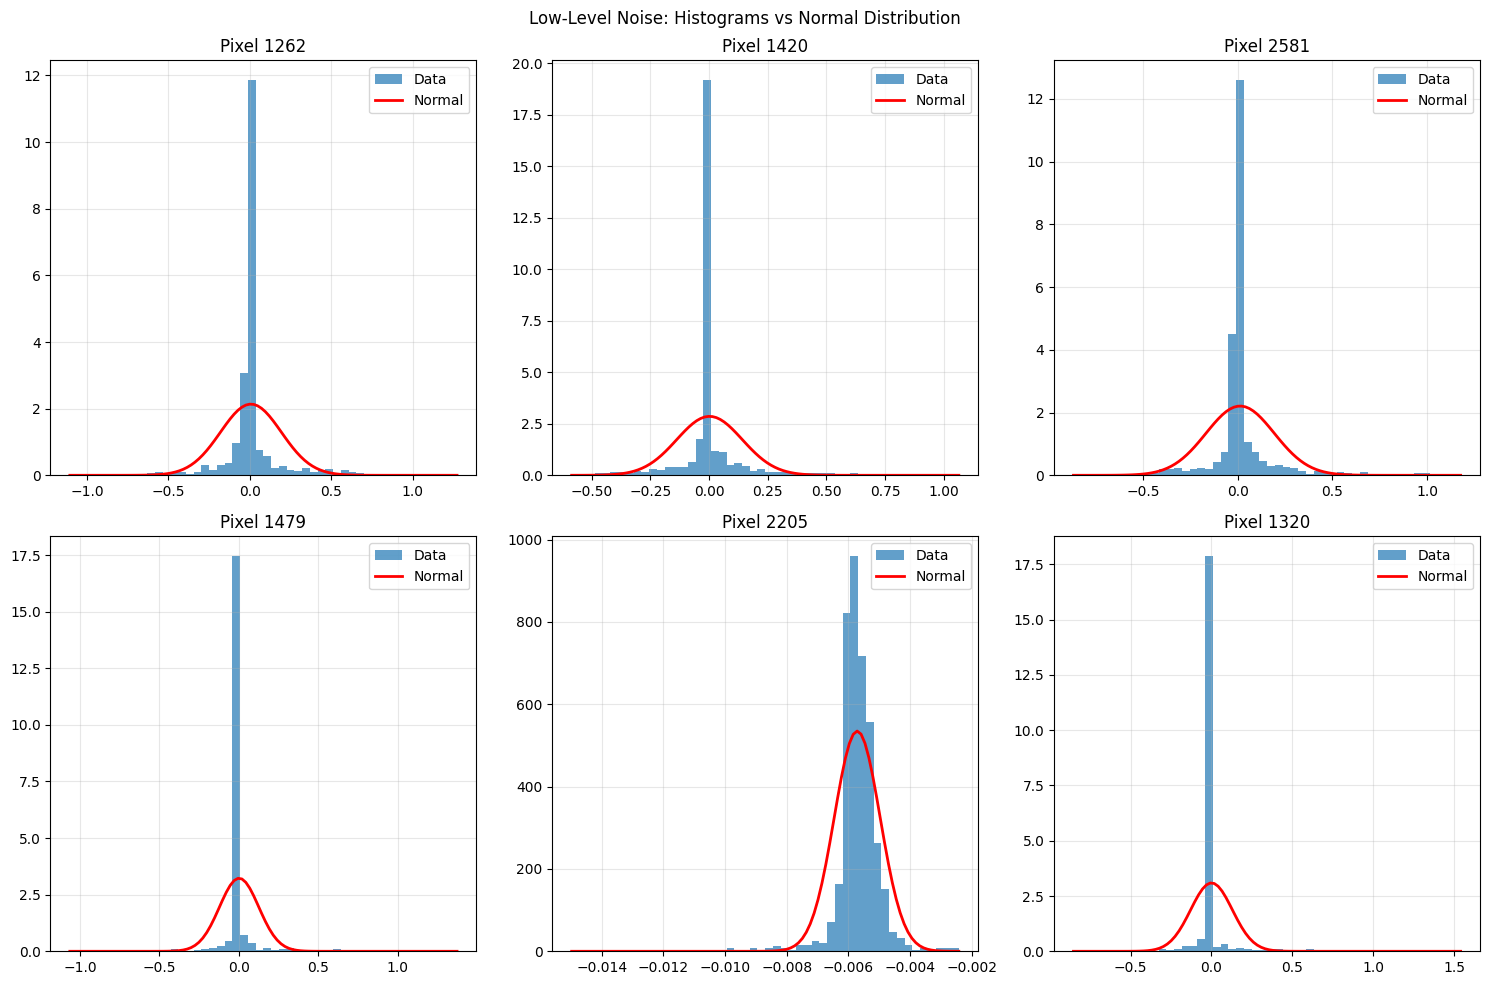

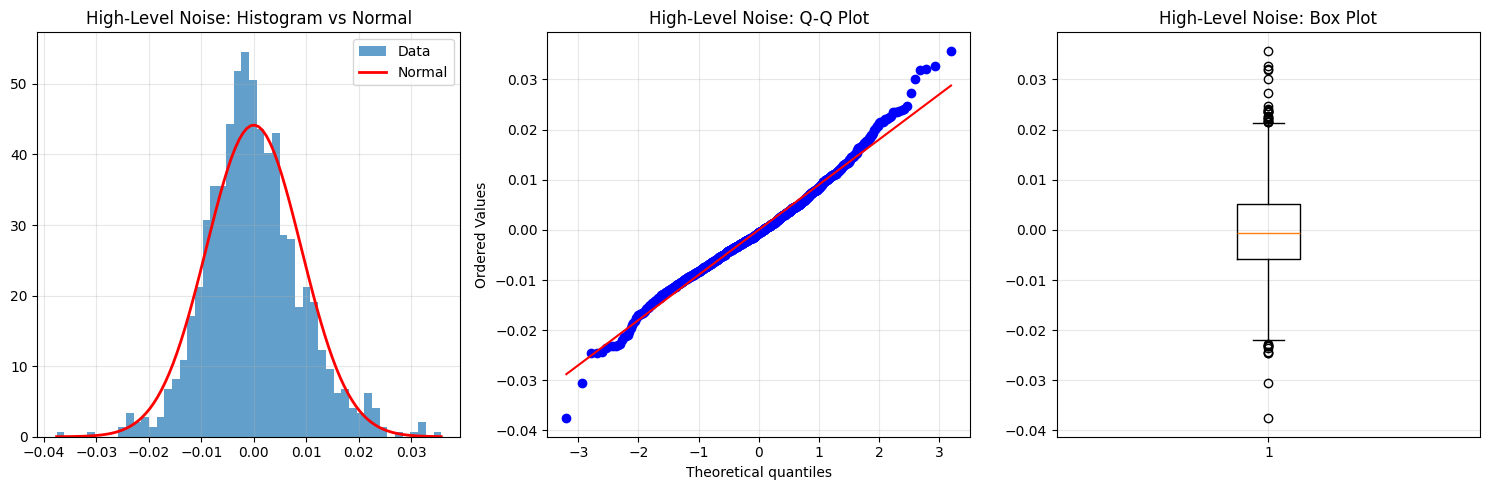


4. SUMMARY STATISTICS
-------------------------
Low-Level Noise:
  Mean of means: 0.000304 (should be ~0)
  Mean of stds: 0.085358
  Mean skewness: 2.693734 (should be ~0)
  Mean kurtosis: 150.129562 (should be ~0)

High-Level Noise:
  Mean: 0.000000 (should be ~0)
  Std: 0.009032
  Skewness: 0.286573 (should be ~0)
  Kurtosis: 1.017319 (should be ~0)

5. GAUSSIANITY INTERPRETATION
-----------------------------------
Low-Level Noise:
✗ Clearly non-Gaussian (p < 0.01)

High-Level Noise:
✗ Clearly non-Gaussian (p < 0.01)

GAUSSIANITY TESTS COMPLETE


In [5]:
# ===== GAUSSIANITY TESTS FOR NOISE =====

import scipy.stats as stats
from scipy.stats import normaltest, shapiro, anderson
import numpy as np
import matplotlib.pyplot as plt

def test_noise_gaussianity(U_ll_hat, U_hl_hat, num_samples=1000):
    """
    Comprehensive Gaussianity tests for both low-level and high-level noise.
    """
    print("=" * 60)
    print("GAUSSIANITY TESTS FOR NOISE")
    print("=" * 60)
    
    # ===== 1. LOW-LEVEL NOISE GAUSSIANITY =====
    print("\n1. LOW-LEVEL NOISE GAUSSIANITY")
    print("-" * 40)
    
    # Flatten low-level noise for analysis
    U_ll_flat = U_ll_hat.view(U_ll_hat.size(0), -1).detach().cpu().numpy()
    
    # Sample random pixels for testing
    n_pixels = min(num_samples, U_ll_flat.shape[1])
    sample_pixels = np.random.choice(U_ll_flat.shape[1], size=n_pixels, replace=False)
    U_ll_samples = U_ll_flat[:, sample_pixels]
    
    # Test each sampled pixel
    ll_results = []
    for i, pixel in enumerate(sample_pixels[:10]):  # Test first 10 pixels
        pixel_data = U_ll_samples[:, i]
        
        # D'Agostino and Pearson's test
        stat_dp, p_dp = normaltest(pixel_data)
        
        # Shapiro-Wilk test (for smaller samples)
        if len(pixel_data) <= 5000:
            stat_sw, p_sw = shapiro(pixel_data)
        else:
            stat_sw, p_sw = np.nan, np.nan
        
        # Anderson-Darling test
        stat_ad, critical_values, significance_levels = anderson(pixel_data, dist='norm')
        
        ll_results.append({
            'pixel': pixel,
            'dp_stat': stat_dp,
            'dp_p': p_dp,
            'sw_stat': stat_sw,
            'sw_p': p_sw,
            'ad_stat': stat_ad,
            'ad_critical': critical_values[2]  # 5% significance level
        })
        
        print(f"Pixel {pixel}:")
        print(f"  D'Agostino-Pearson: stat={stat_dp:.4f}, p={p_dp:.4f}")
        if not np.isnan(p_sw):
            print(f"  Shapiro-Wilk: stat={stat_sw:.4f}, p={p_sw:.4f}")
        print(f"  Anderson-Darling: stat={stat_ad:.4f}, critical={critical_values[2]:.4f}")
        print()
    
    # ===== 2. HIGH-LEVEL NOISE GAUSSIANITY =====
    print("\n2. HIGH-LEVEL NOISE GAUSSIANITY")
    print("-" * 40)
    
    U_hl_flat = U_hl_hat.detach().cpu().numpy().flatten()
    
    # D'Agostino and Pearson's test
    stat_dp, p_dp = normaltest(U_hl_flat)
    
    # Shapiro-Wilk test
    if len(U_hl_flat) <= 5000:
        stat_sw, p_sw = shapiro(U_hl_flat)
    else:
        stat_sw, p_sw = np.nan, np.nan
    
    # Anderson-Darling test
    stat_ad, critical_values, significance_levels = anderson(U_hl_flat, dist='norm')
    
    print(f"D'Agostino-Pearson: stat={stat_dp:.4f}, p={p_dp:.4f}")
    if not np.isnan(p_sw):
        print(f"Shapiro-Wilk: stat={stat_sw:.4f}, p={p_sw:.4f}")
    print(f"Anderson-Darling: stat={stat_ad:.4f}, critical={critical_values[2]:.4f}")
    
    # ===== 3. VISUAL GAUSSIANITY CHECKS =====
    print("\n3. VISUAL GAUSSIANITY CHECKS")
    print("-" * 35)
    
    # Low-level noise visualization
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Sample a few pixels for visualization
    sample_pixels_viz = sample_pixels[:6]
    
    for i, pixel in enumerate(sample_pixels_viz):
        row, col = i // 3, i % 3
        
        # Histogram
        pixel_data = U_ll_samples[:, i]
        axes[row, col].hist(pixel_data, bins=50, density=True, alpha=0.7, label='Data')
        
        # Overlay normal distribution
        mu, sigma = pixel_data.mean(), pixel_data.std()
        x = np.linspace(pixel_data.min(), pixel_data.max(), 100)
        axes[row, col].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='Normal')
        axes[row, col].set_title(f'Pixel {pixel}')
        axes[row, col].legend()
        axes[row, col].grid(True, alpha=0.3)
    
    plt.suptitle('Low-Level Noise: Histograms vs Normal Distribution')
    plt.tight_layout()
    plt.show()
    
    # High-level noise visualization
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Histogram
    axes[0].hist(U_hl_flat, bins=50, density=True, alpha=0.7, label='Data')
    mu_hl, sigma_hl = U_hl_flat.mean(), U_hl_flat.std()
    x_hl = np.linspace(U_hl_flat.min(), U_hl_flat.max(), 100)
    axes[0].plot(x_hl, stats.norm.pdf(x_hl, mu_hl, sigma_hl), 'r-', linewidth=2, label='Normal')
    axes[0].set_title('High-Level Noise: Histogram vs Normal')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Q-Q plot
    stats.probplot(U_hl_flat, dist="norm", plot=axes[1])
    axes[1].set_title('High-Level Noise: Q-Q Plot')
    axes[1].grid(True, alpha=0.3)
    
    # Box plot
    axes[2].boxplot(U_hl_flat)
    axes[2].set_title('High-Level Noise: Box Plot')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # ===== 4. SUMMARY STATISTICS =====
    print("\n4. SUMMARY STATISTICS")
    print("-" * 25)
    
    # Low-level noise summary
    ll_means = U_ll_samples.mean(axis=0)
    ll_stds = U_ll_samples.std(axis=0)
    ll_skews = stats.skew(U_ll_samples, axis=0)
    ll_kurtoses = stats.kurtosis(U_ll_samples, axis=0)
    
    print("Low-Level Noise:")
    print(f"  Mean of means: {ll_means.mean():.6f} (should be ~0)")
    print(f"  Mean of stds: {ll_stds.mean():.6f}")
    print(f"  Mean skewness: {ll_skews.mean():.6f} (should be ~0)")
    print(f"  Mean kurtosis: {ll_kurtoses.mean():.6f} (should be ~0)")
    
    # High-level noise summary
    print("\nHigh-Level Noise:")
    print(f"  Mean: {U_hl_flat.mean():.6f} (should be ~0)")
    print(f"  Std: {U_hl_flat.std():.6f}")
    print(f"  Skewness: {stats.skew(U_hl_flat):.6f} (should be ~0)")
    print(f"  Kurtosis: {stats.kurtosis(U_hl_flat):.6f} (should be ~0)")
    
    # ===== 5. GAUSSIANITY INTERPRETATION =====
    print("\n5. GAUSSIANITY INTERPRETATION")
    print("-" * 35)
    
    # Low-level interpretation
    dp_p_values = [r['dp_p'] for r in ll_results]
    mean_dp_p = np.mean(dp_p_values)
    
    print("Low-Level Noise:")
    if mean_dp_p > 0.05:
        print("✓ Appears Gaussian (p > 0.05 for D'Agostino-Pearson test)")
    elif mean_dp_p > 0.01:
        print("⚠ Moderately non-Gaussian (0.01 < p < 0.05)")
    else:
        print("✗ Clearly non-Gaussian (p < 0.01)")
    
    # High-level interpretation
    print("\nHigh-Level Noise:")
    if p_dp > 0.05:
        print("✓ Appears Gaussian (p > 0.05 for D'Agostino-Pearson test)")
    elif p_dp > 0.01:
        print("⚠ Moderately non-Gaussian (0.01 < p < 0.05)")
    else:
        print("✗ Clearly non-Gaussian (p < 0.01)")
    
    print("\n" + "=" * 60)
    print("GAUSSIANITY TESTS COMPLETE")
    print("=" * 60)
    
    return {
        'll_results': ll_results,
        'hl_dp_stat': stat_dp,
        'hl_dp_p': p_dp,
        'hl_sw_stat': stat_sw,
        'hl_sw_p': p_sw,
        'hl_ad_stat': stat_ad,
        'hl_ad_critical': critical_values[2]
    }

# Run Gaussianity tests
gaussianity_results = test_noise_gaussianity(U_ll_hat, U_hl_hat)

In [6]:
from sklearn.metrics import r2_score

print("\n--- High-Level Model R² Test ---")
features_hl = hl_obs_data[:, :-1].numpy()
target_hl = hl_obs_data[:, -1].numpy()

# Use .score if available, else fallback to r2_score on predictions
try:
    r2_hl = hl_model.score(features_hl, target_hl)
except AttributeError:
    hl_preds = hl_model.predict(features_hl)
    r2_hl = r2_score(target_hl, hl_preds)

print(f"High-Level Model ({type(hl_model).__name__}):")
print(f"  - R-squared (R²): {r2_hl:.4f}")


--- High-Level Model R² Test ---
High-Level Model (LinearRegression):
  - R-squared (R²): 0.6096
